# Two-Foil Single Read Analysis - CCB Foil 1

This notebook analyzes foil #1 from the CCB experiment — a single image containing 
two detector circles (8-shaped figure) taken in one read.

Pipeline:
1. Load preprocessed data and reference circle distance from merged foils 2 & 3
2. Visualize the detector image with colormap
3. Estimate two circle positions using known inter-circle distance
4. Refine circles with gradient-based edge detection
5. Rotate image to align circle centers horizontally
6. Extract and visualize horizontal profiles

In [23]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd()
while not (project_root / 'pyproject.toml').exists() and project_root != project_root.parent:
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

In [24]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.optimize import minimize
from scipy.ndimage import gaussian_filter1d
import scipy.ndimage as ndi

from src.data.analysis import Circle

## Configuration

In [25]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# Data path
DATA_PATH = Path(r"C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\foils_mbo_ccb\2026-02-20")

# Foil ID (single read with two detectors)
FOIL_ID = 1

# Pixel to mm conversion (MBO foils CCB experiment)
PIXEL_SIZE_MM = 0.074           # mm per pixel (74 µm)

# Visualization
VMAX = 3000                     # Max intensity for colormap
WHITE_THRESHOLD = 0.05          # Fraction of VMAX below which color is white (0-1)

# Circle Detection Parameters (gradient-based)
CIRCLE_GRADIENT_HIGH = 300      # Upper threshold for gradient detection
CIRCLE_GRADIENT_LOW = 200       # Lower threshold for gradient detection
CIRCLE_EDGE_DISTANCE_MM = 0.5   # Max distance from initial circle edge (mm)
CIRCLE_RADIUS_TOLERANCE = 0.05  # Allowed radius deviation (5%)

# Profile parameters
PROFILE_Y_MIN_MM = 9            # Y range for averaging
PROFILE_Y_MAX_MM = 13
SMOOTHING_SIGMA = 4             # Gaussian smoothing in pixels

# Custom colormap: white (0-5%) -> green (50%) -> red (100%)
CMAP = LinearSegmentedColormap.from_list('white_green_red', [
    (0.0, (1.0, 1.0, 1.0, 1.0)),                    # 0% = white
    (WHITE_THRESHOLD, (1.0, 1.0, 1.0, 1.0)),        # WHITE_THRESHOLD% = white
    (0.5, (0.0, 1.0, 0.0, 1.0)),                    # 50% = green
    (1.0, (1.0, 0.0, 0.0, 1.0)),                    # 100% = red
])

print(f"Configuration loaded. Data path: {DATA_PATH}")

Configuration loaded. Data path: C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\foils_mbo_ccb\2026-02-20


## Load Data

Load foil 1 from preprocessed pickle and reference circle distance from merged foils 2 & 3.

In [26]:
# Load preprocessed data (from 0.1-explore-ccb.ipynb)
with open(DATA_PATH / 'mbo_ccb_processed.pkl', 'rb') as f:
    data = pickle.load(f)

# Extract and flip image (fliplr for consistent orientation)
image = np.fliplr(data.data[FOIL_ID].raw.image)

# Flip circle X coordinate to match flipped image
hough_circle = Circle(
    x=image.shape[1] - data.data[FOIL_ID].circle.x,
    y=data.data[FOIL_ID].circle.y,
    r=data.data[FOIL_ID].circle.r
)

print(f"Foil {FOIL_ID} image shape: {image.shape}")
print(f"Hough circle: ({hough_circle.x:.1f}, {hough_circle.y:.1f}) px, r={hough_circle.r:.1f} px")
print(f"Hough circle (mm): center=({hough_circle.x * PIXEL_SIZE_MM:.2f}, {hough_circle.y * PIXEL_SIZE_MM:.2f}), r={hough_circle.r * PIXEL_SIZE_MM:.2f}")

Foil 1 image shape: (624, 624)
Hough circle: (305.5, 382.5) px, r=134.2 px
Hough circle (mm): center=(22.61, 28.30), r=9.93


In [27]:
# Load reference circle distance from merged foils 2 & 3 (from 0.2-match-ccb.ipynb)
ref_data = np.load(DATA_PATH / 'merged_foils_2_3.npz')

ref_left_circle = Circle(
    x=float(ref_data['left_circle_opt_x']),
    y=float(ref_data['left_circle_opt_y']),
    r=float(ref_data['left_circle_opt_r'])
)
ref_right_circle = Circle(
    x=float(ref_data['right_circle_opt_x']),
    y=float(ref_data['right_circle_opt_y']),
    r=float(ref_data['right_circle_opt_r'])
)

# Calculate reference inter-circle distance and average radius
ref_distance_px = np.sqrt(
    (ref_right_circle.x - ref_left_circle.x)**2 +
    (ref_right_circle.y - ref_left_circle.y)**2
)
ref_distance_mm = ref_distance_px * PIXEL_SIZE_MM
ref_avg_radius = (ref_left_circle.r + ref_right_circle.r) / 2

print(f"Reference from merged foils 2 & 3:")
print(f"  Inter-circle distance: {ref_distance_mm:.2f} mm ({ref_distance_px:.1f} px)")
print(f"  Average radius: {ref_avg_radius:.1f} px ({ref_avg_radius * PIXEL_SIZE_MM:.2f} mm)")

Reference from merged foils 2 & 3:
  Inter-circle distance: 15.18 mm (205.1 px)
  Average radius: 132.9 px (9.83 mm)


## Visualize Detector Image

Single image containing two detector circles (8-shaped figure).

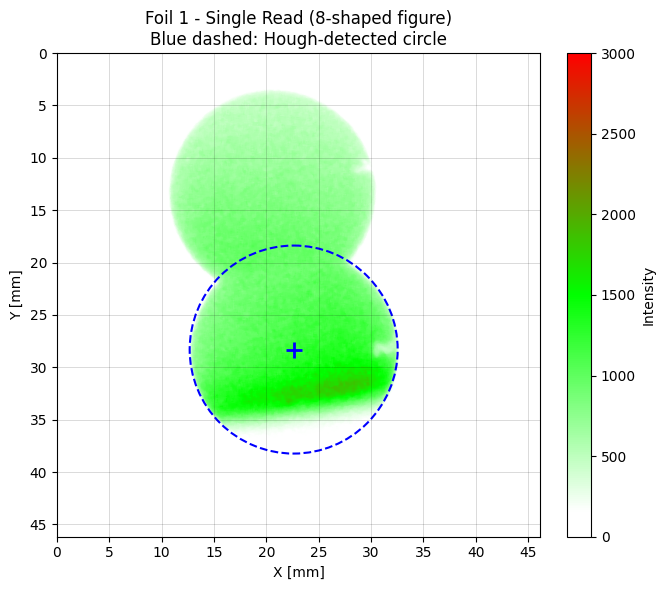

In [28]:
# Visualize foil 1 with the single Hough-detected circle
fig, ax = plt.subplots(figsize=(14, 6))

h, w = image.shape
extent_mm = [0, w * PIXEL_SIZE_MM, h * PIXEL_SIZE_MM, 0]

im = ax.imshow(image, cmap=CMAP, vmin=0, vmax=VMAX, extent=extent_mm)

# Draw Hough circle (blue dashed)
cx_mm = hough_circle.x * PIXEL_SIZE_MM
cy_mm = hough_circle.y * PIXEL_SIZE_MM
r_mm = hough_circle.r * PIXEL_SIZE_MM
ax.add_patch(plt.Circle((cx_mm, cy_mm), r_mm, color='blue', fill=False, lw=1.5, linestyle='--'))
ax.plot(cx_mm, cy_mm, marker='+', color='blue', ms=12, mew=2)

ax.set_title(f'Foil {FOIL_ID} - Single Read (8-shaped figure)\nBlue dashed: Hough-detected circle')
ax.set_xlabel('X [mm]')
ax.set_ylabel('Y [mm]')

ax.set_xticks(np.arange(0, w * PIXEL_SIZE_MM + 1, 5))
ax.set_yticks(np.arange(0, h * PIXEL_SIZE_MM + 1, 5))
ax.grid(True, color='k', alpha=0.2, lw=0.5)

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='Intensity')
plt.tight_layout()
plt.show()

## Estimate Two Circle Positions

Use the known inter-circle distance from merged foils 2 & 3 and image moment 
analysis to estimate the positions of both detector circles.

In [29]:
# Estimate two circle centers using image moments (PCA on thresholded image)
# to find the major axis orientation, then place circles at known distance

# Threshold image to find signal region
binary = image > CIRCLE_GRADIENT_LOW
coords = np.argwhere(binary)  # (y, x) coordinates

# Global center of mass of signal region
cy_global, cx_global = ndi.center_of_mass(image, labels=binary.astype(int), index=1)
print(f"Global center of mass: ({cx_global:.1f}, {cy_global:.1f}) px")
print(f"  in mm: ({cx_global * PIXEL_SIZE_MM:.2f}, {cy_global * PIXEL_SIZE_MM:.2f})")

# Compute inertia tensor to find principal axis
y_centered = coords[:, 0] - cy_global
x_centered = coords[:, 1] - cx_global

Ixx = np.sum(x_centered**2)
Iyy = np.sum(y_centered**2)
Ixy = np.sum(x_centered * y_centered)

# Principal axis angle (eigenvector of inertia tensor)
theta = 0.5 * np.arctan2(2 * Ixy, Ixx - Iyy)
print(f"Major axis angle: {np.degrees(theta):.2f}° from horizontal")

# Place two initial circles along the major axis at ±(distance/2) from center
half_dist = ref_distance_px / 2

circle1_initial = Circle(
    x=cx_global - half_dist * np.cos(theta),
    y=cy_global - half_dist * np.sin(theta),
    r=ref_avg_radius
)
circle2_initial = Circle(
    x=cx_global + half_dist * np.cos(theta),
    y=cy_global + half_dist * np.sin(theta),
    r=ref_avg_radius
)

# Ensure circle1 is the left one (smaller x)
if circle1_initial.x > circle2_initial.x:
    circle1_initial, circle2_initial = circle2_initial, circle1_initial

est_distance_mm = np.sqrt(
    (circle2_initial.x - circle1_initial.x)**2 +
    (circle2_initial.y - circle1_initial.y)**2
) * PIXEL_SIZE_MM

print(f"\nEstimated circle positions:")
print(f"  Circle 1 (left):  ({circle1_initial.x:.1f}, {circle1_initial.y:.1f}) px, r={circle1_initial.r:.1f} px")
print(f"  Circle 2 (right): ({circle2_initial.x:.1f}, {circle2_initial.y:.1f}) px, r={circle2_initial.r:.1f} px")
print(f"  Distance: {est_distance_mm:.2f} mm (reference: {ref_distance_mm:.2f} mm)")

Global center of mass: (294.8, 301.6) px
  in mm: (21.82, 22.32)
Major axis angle: 81.86° from horizontal

Estimated circle positions:
  Circle 1 (left):  (280.3, 200.1) px, r=132.9 px
  Circle 2 (right): (309.4, 403.1) px, r=132.9 px
  Distance: 15.18 mm (reference: 15.18 mm)


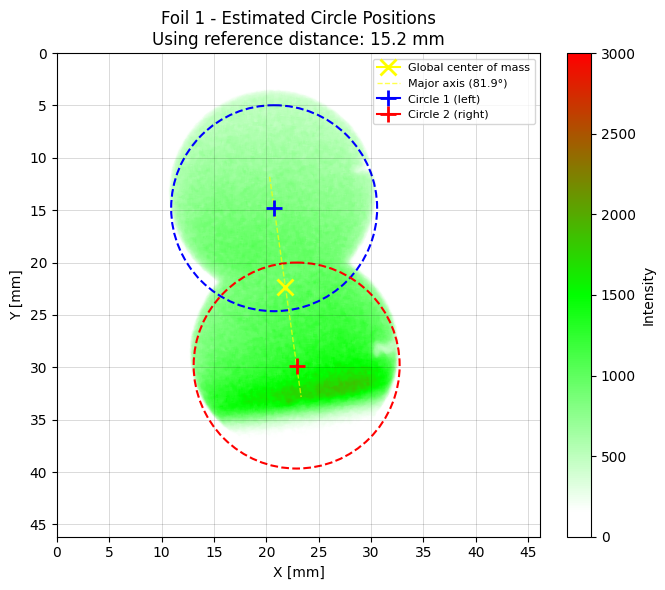

In [30]:
# Visualize estimated circle positions
fig, ax = plt.subplots(figsize=(14, 6))

h, w = image.shape
extent_mm = [0, w * PIXEL_SIZE_MM, h * PIXEL_SIZE_MM, 0]

im = ax.imshow(image, cmap=CMAP, vmin=0, vmax=VMAX, extent=extent_mm)

# Global center of mass
ax.plot(cx_global * PIXEL_SIZE_MM, cy_global * PIXEL_SIZE_MM,
        marker='x', color='yellow', ms=12, mew=2, label='Global center of mass')

# Major axis line through center
axis_len = ref_distance_px * 0.7
ax.plot(
    [(cx_global - axis_len * np.cos(theta)) * PIXEL_SIZE_MM,
     (cx_global + axis_len * np.cos(theta)) * PIXEL_SIZE_MM],
    [(cy_global - axis_len * np.sin(theta)) * PIXEL_SIZE_MM,
     (cy_global + axis_len * np.sin(theta)) * PIXEL_SIZE_MM],
    'yellow', lw=1, linestyle='--', alpha=0.7, label=f'Major axis ({np.degrees(theta):.1f}°)')

# Estimated circles
for circle, label, color in [
    (circle1_initial, 'Circle 1 (left)', 'blue'),
    (circle2_initial, 'Circle 2 (right)', 'red')
]:
    cx_mm = circle.x * PIXEL_SIZE_MM
    cy_mm = circle.y * PIXEL_SIZE_MM
    r_mm = circle.r * PIXEL_SIZE_MM
    ax.add_patch(plt.Circle((cx_mm, cy_mm), r_mm, color=color, fill=False, lw=1.5, linestyle='--'))
    ax.plot(cx_mm, cy_mm, marker='+', color=color, ms=12, mew=2, label=label)

ax.set_title(f'Foil {FOIL_ID} - Estimated Circle Positions\n'
             f'Using reference distance: {ref_distance_mm:.1f} mm')
ax.set_xlabel('X [mm]')
ax.set_ylabel('Y [mm]')

ax.set_xticks(np.arange(0, w * PIXEL_SIZE_MM + 1, 5))
ax.set_yticks(np.arange(0, h * PIXEL_SIZE_MM + 1, 5))
ax.grid(True, color='k', alpha=0.2, lw=0.5)

ax.legend(fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='Intensity')
plt.tight_layout()
plt.show()

## Gradient-Based Circle Detection

Refine circle positions using gradient-based edge detection:
1. Detect intensity gradient where signal drops from HIGH to LOW threshold
2. Filter edge points within specified distance from initial circle
3. Fit new circle constrained to ±5% of initial radius

In [31]:
def find_gradient_edge_points(image, center_x, center_y, high_thresh, low_thresh):
    """
    Find edge points where intensity drops from high_thresh to low_thresh.
    Uses radial scanning from center to find transition zones.
    """
    h, w = image.shape
    edge_points = []
    
    # Scan radially in multiple directions
    n_angles = 360
    for angle_idx in range(n_angles):
        angle = 2 * np.pi * angle_idx / n_angles
        
        # Scan along ray from center outward
        max_radius = min(h, w) // 2
        prev_val = None
        in_transition = False
        transition_start = None
        
        for r in range(10, max_radius):
            x = int(center_x + r * np.cos(angle))
            y = int(center_y + r * np.sin(angle))
            
            if 0 <= x < w and 0 <= y < h:
                val = image[y, x]
                
                if prev_val is not None:
                    # Detect start of transition zone
                    if not in_transition and prev_val > high_thresh and val <= high_thresh:
                        in_transition = True
                        transition_start = (x, y)
                    
                    # Detect end of transition
                    if in_transition and val < low_thresh:
                        if transition_start is not None:
                            mid_x = (transition_start[0] + x) // 2
                            mid_y = (transition_start[1] + y) // 2
                            edge_points.append((mid_x, mid_y))
                        in_transition = False
                        transition_start = None
                        break
                
                prev_val = val
    
    return edge_points


def filter_edge_points_near_circle(edge_points, circle, max_distance_px):
    """Filter edge points to only keep those within max_distance from the circle edge."""
    filtered = []
    for x, y in edge_points:
        dist_to_center = np.sqrt((x - circle.x)**2 + (y - circle.y)**2)
        dist_to_edge = abs(dist_to_center - circle.r)
        if dist_to_edge <= max_distance_px:
            filtered.append((x, y))
    return filtered


def fit_circle_to_points(points, initial_circle, radius_tolerance):
    """Fit a circle to points with radius constrained within tolerance of initial."""
    if len(points) < 10:
        print(f"Warning: Only {len(points)} points, keeping initial circle")
        return initial_circle
    
    points_arr = np.array(points)
    x_pts, y_pts = points_arr[:, 0], points_arr[:, 1]
    
    min_r = initial_circle.r * (1 - radius_tolerance)
    max_r = initial_circle.r * (1 + radius_tolerance)
    
    def objective(params):
        cx, cy, r = params
        distances = np.sqrt((x_pts - cx)**2 + (y_pts - cy)**2)
        return np.sum((distances - r)**2)
    
    x0 = [initial_circle.x, initial_circle.y, initial_circle.r]
    bounds = [(None, None), (None, None), (min_r, max_r)]
    
    result = minimize(objective, x0, method='L-BFGS-B', bounds=bounds)
    
    return Circle(x=result.x[0], y=result.x[1], r=result.x[2])

In [32]:
# Detect edge points for both circles
max_dist_px = CIRCLE_EDGE_DISTANCE_MM / PIXEL_SIZE_MM

print("Detecting Circle 1 (left)...")
circle1_edge_pts = find_gradient_edge_points(
    image, circle1_initial.x, circle1_initial.y,
    CIRCLE_GRADIENT_HIGH, CIRCLE_GRADIENT_LOW
)
circle1_filtered_pts = filter_edge_points_near_circle(circle1_edge_pts, circle1_initial, max_dist_px)
print(f"  Found {len(circle1_edge_pts)} edge points, {len(circle1_filtered_pts)} within {CIRCLE_EDGE_DISTANCE_MM}mm")

print("\nDetecting Circle 2 (right)...")
circle2_edge_pts = find_gradient_edge_points(
    image, circle2_initial.x, circle2_initial.y,
    CIRCLE_GRADIENT_HIGH, CIRCLE_GRADIENT_LOW
)
circle2_filtered_pts = filter_edge_points_near_circle(circle2_edge_pts, circle2_initial, max_dist_px)
print(f"  Found {len(circle2_edge_pts)} edge points, {len(circle2_filtered_pts)} within {CIRCLE_EDGE_DISTANCE_MM}mm")

Detecting Circle 1 (left)...
  Found 360 edge points, 79 within 0.5mm

Detecting Circle 2 (right)...
  Found 315 edge points, 74 within 0.5mm


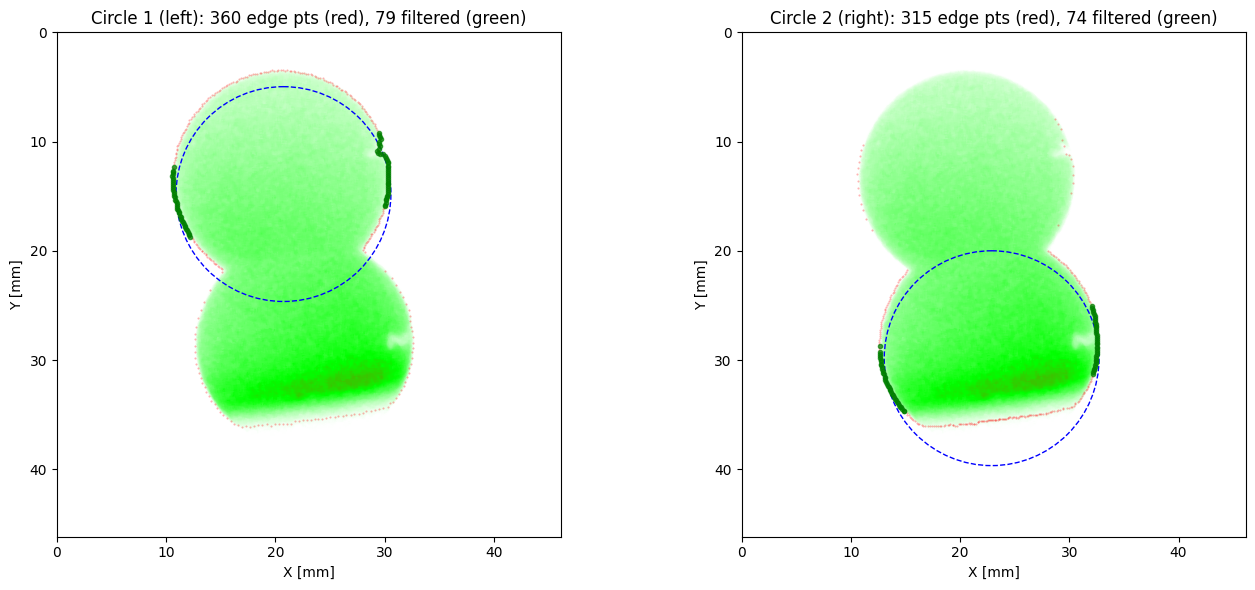

In [33]:
# Visualize gradient edge detection
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

extent_mm = [0, image.shape[1] * PIXEL_SIZE_MM, image.shape[0] * PIXEL_SIZE_MM, 0]

for ax, circle, edge_pts, filtered_pts, title in [
    (axes[0], circle1_initial, circle1_edge_pts, circle1_filtered_pts, 'Circle 1 (left)'),
    (axes[1], circle2_initial, circle2_edge_pts, circle2_filtered_pts, 'Circle 2 (right)')
]:
    ax.imshow(image, cmap=CMAP, vmin=0, vmax=VMAX, extent=extent_mm)
    
    # Initial circle (blue dashed)
    ax.add_patch(plt.Circle((circle.x * PIXEL_SIZE_MM, circle.y * PIXEL_SIZE_MM),
                            circle.r * PIXEL_SIZE_MM, color='blue', fill=False, lw=1, linestyle='--'))
    
    # All edge points (red)
    for x, y in edge_pts:
        ax.plot(x * PIXEL_SIZE_MM, y * PIXEL_SIZE_MM, 'r.', ms=1, alpha=0.3)
    # Filtered edge points (green)
    for x, y in filtered_pts:
        ax.plot(x * PIXEL_SIZE_MM, y * PIXEL_SIZE_MM, 'go', ms=3, alpha=0.7)
    
    ax.set_title(f'{title}: {len(edge_pts)} edge pts (red), {len(filtered_pts)} filtered (green)')
    ax.set_xlabel('X [mm]')
    ax.set_ylabel('Y [mm]')

plt.tight_layout()
plt.show()

In [34]:
# Fit refined circles
circle1_refined = fit_circle_to_points(circle1_filtered_pts, circle1_initial, CIRCLE_RADIUS_TOLERANCE)
circle2_refined = fit_circle_to_points(circle2_filtered_pts, circle2_initial, CIRCLE_RADIUS_TOLERANCE)

print("Circle comparison:")
print(f"\nCircle 1 (left):")
print(f"  Initial:  center=({circle1_initial.x:.2f}, {circle1_initial.y:.2f}) px, r={circle1_initial.r:.2f} px")
print(f"  Refined:  center=({circle1_refined.x:.2f}, {circle1_refined.y:.2f}) px, r={circle1_refined.r:.2f} px")
print(f"  Center shift: ({(circle1_refined.x - circle1_initial.x)*PIXEL_SIZE_MM:.3f}, {(circle1_refined.y - circle1_initial.y)*PIXEL_SIZE_MM:.3f}) mm")
print(f"  Radius change: {(circle1_refined.r - circle1_initial.r)*PIXEL_SIZE_MM:.3f} mm ({100*(circle1_refined.r/circle1_initial.r - 1):.2f}%)")

print(f"\nCircle 2 (right):")
print(f"  Initial:  center=({circle2_initial.x:.2f}, {circle2_initial.y:.2f}) px, r={circle2_initial.r:.2f} px")
print(f"  Refined:  center=({circle2_refined.x:.2f}, {circle2_refined.y:.2f}) px, r={circle2_refined.r:.2f} px")
print(f"  Center shift: ({(circle2_refined.x - circle2_initial.x)*PIXEL_SIZE_MM:.3f}, {(circle2_refined.y - circle2_initial.y)*PIXEL_SIZE_MM:.3f}) mm")
print(f"  Radius change: {(circle2_refined.r - circle2_initial.r)*PIXEL_SIZE_MM:.3f} mm ({100*(circle2_refined.r/circle2_initial.r - 1):.2f}%)")

# Distance between refined circles
refined_distance_px = np.sqrt(
    (circle2_refined.x - circle1_refined.x)**2 +
    (circle2_refined.y - circle1_refined.y)**2
)
refined_distance_mm = refined_distance_px * PIXEL_SIZE_MM
print(f"\nDistance between refined circles: {refined_distance_mm:.2f} mm (reference: {ref_distance_mm:.2f} mm)")

Circle comparison:

Circle 1 (left):
  Initial:  center=(280.31, 200.10) px, r=132.89 px
  Refined:  center=(276.82, 183.25) px, r=132.31 px
  Center shift: (-0.258, -1.247) mm
  Radius change: -0.043 mm (-0.44%)

Circle 2 (right):
  Initial:  center=(309.36, 403.13) px, r=132.89 px
  Refined:  center=(305.14, 383.12) px, r=135.07 px
  Center shift: (-0.312, -1.481) mm
  Radius change: 0.161 mm (1.64%)

Distance between refined circles: 14.94 mm (reference: 15.18 mm)


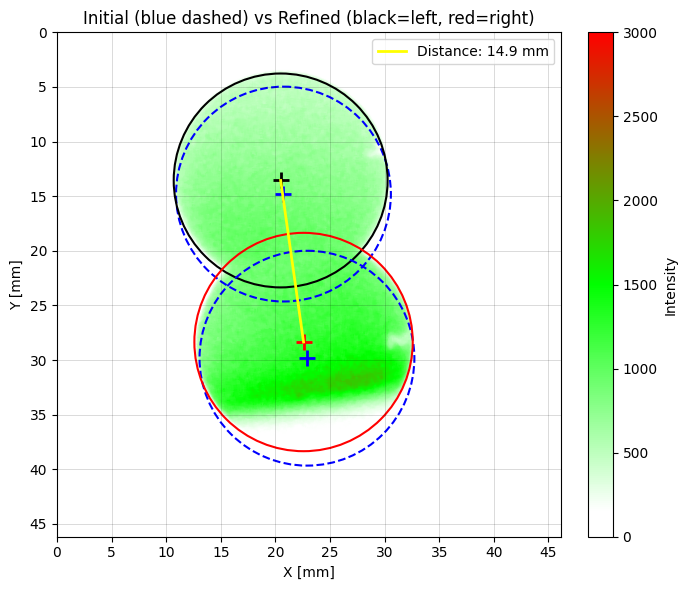

In [35]:
# Visualize initial vs refined circles
fig, ax = plt.subplots(figsize=(14, 6))

extent_mm = [0, image.shape[1] * PIXEL_SIZE_MM, image.shape[0] * PIXEL_SIZE_MM, 0]
im = ax.imshow(image, cmap=CMAP, vmin=0, vmax=VMAX, extent=extent_mm)

# Circle 1: initial (blue dashed) and refined (black solid)
ax.add_patch(plt.Circle((circle1_initial.x * PIXEL_SIZE_MM, circle1_initial.y * PIXEL_SIZE_MM),
                        circle1_initial.r * PIXEL_SIZE_MM, color='blue', fill=False, lw=1.5, linestyle='--'))
ax.plot(circle1_initial.x * PIXEL_SIZE_MM, circle1_initial.y * PIXEL_SIZE_MM, 'b+', ms=12, mew=2)

ax.add_patch(plt.Circle((circle1_refined.x * PIXEL_SIZE_MM, circle1_refined.y * PIXEL_SIZE_MM),
                        circle1_refined.r * PIXEL_SIZE_MM, color='black', fill=False, lw=1.5))
ax.plot(circle1_refined.x * PIXEL_SIZE_MM, circle1_refined.y * PIXEL_SIZE_MM, 'k+', ms=12, mew=2)

# Circle 2: initial (blue dashed) and refined (red solid)
ax.add_patch(plt.Circle((circle2_initial.x * PIXEL_SIZE_MM, circle2_initial.y * PIXEL_SIZE_MM),
                        circle2_initial.r * PIXEL_SIZE_MM, color='blue', fill=False, lw=1.5, linestyle='--'))
ax.plot(circle2_initial.x * PIXEL_SIZE_MM, circle2_initial.y * PIXEL_SIZE_MM, 'b+', ms=12, mew=2)

ax.add_patch(plt.Circle((circle2_refined.x * PIXEL_SIZE_MM, circle2_refined.y * PIXEL_SIZE_MM),
                        circle2_refined.r * PIXEL_SIZE_MM, color='red', fill=False, lw=1.5))
ax.plot(circle2_refined.x * PIXEL_SIZE_MM, circle2_refined.y * PIXEL_SIZE_MM, 'r+', ms=12, mew=2)

# Line between refined centers
ax.plot(
    [circle1_refined.x * PIXEL_SIZE_MM, circle2_refined.x * PIXEL_SIZE_MM],
    [circle1_refined.y * PIXEL_SIZE_MM, circle2_refined.y * PIXEL_SIZE_MM],
    'yellow', lw=2, label=f'Distance: {refined_distance_mm:.1f} mm'
)

ax.set_title(f'Initial (blue dashed) vs Refined (black=left, red=right)')
ax.set_xlabel('X [mm]')
ax.set_ylabel('Y [mm]')

ax.set_xticks(np.arange(0, image.shape[1] * PIXEL_SIZE_MM + 1, 5))
ax.set_yticks(np.arange(0, image.shape[0] * PIXEL_SIZE_MM + 1, 5))
ax.grid(True, color='k', alpha=0.2, lw=0.5)

ax.legend()
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='Intensity')
plt.tight_layout()
plt.show()

## Rotate Image for Horizontal Alignment

Calculate the angle between the two circle centers and rotate the image
to make them horizontally aligned.

Circle center distance: 14.94 mm
Current angle: 81.94° (from horizontal)
Rotation needed: -81.94° to align horizontally


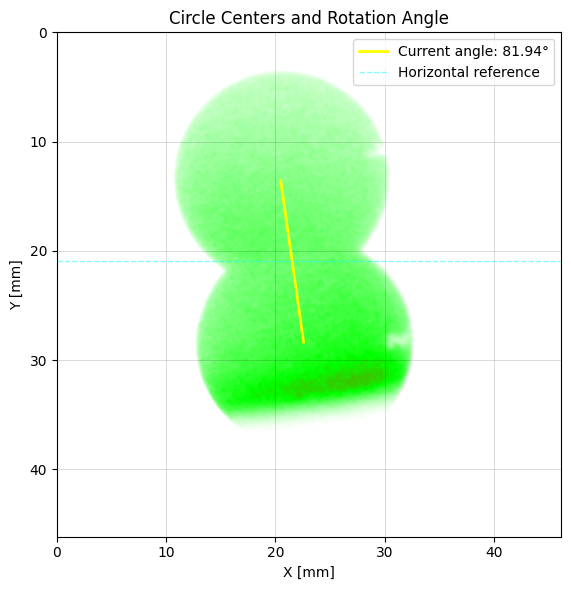

In [36]:
# Calculate angle between circle centers
dx = circle2_refined.x - circle1_refined.x
dy = circle2_refined.y - circle1_refined.y

angle_rad = np.arctan2(dy, dx)
angle_deg = np.degrees(angle_rad)

print(f"Circle center distance: {np.sqrt(dx**2 + dy**2) * PIXEL_SIZE_MM:.2f} mm")
print(f"Current angle: {angle_deg:.2f}° (from horizontal)")
print(f"Rotation needed: {-angle_deg:.2f}° to align horizontally")

# Visualize current angle
fig, ax = plt.subplots(figsize=(14, 6))
extent_mm = [0, image.shape[1] * PIXEL_SIZE_MM, image.shape[0] * PIXEL_SIZE_MM, 0]
ax.imshow(image, cmap=CMAP, vmin=0, vmax=VMAX, extent=extent_mm)

# Draw line between centers
ax.plot(
    [circle1_refined.x * PIXEL_SIZE_MM, circle2_refined.x * PIXEL_SIZE_MM],
    [circle1_refined.y * PIXEL_SIZE_MM, circle2_refined.y * PIXEL_SIZE_MM],
    'yellow', lw=2, label=f'Current angle: {angle_deg:.2f}°'
)

# Draw horizontal reference line
mid_y = (circle1_refined.y + circle2_refined.y) / 2
ax.axhline(y=mid_y * PIXEL_SIZE_MM, color='cyan', linestyle='--', lw=1, alpha=0.5, label='Horizontal reference')

ax.legend()
ax.set_title('Circle Centers and Rotation Angle')
ax.set_xlabel('X [mm]')
ax.set_ylabel('Y [mm]')
ax.grid(True, color='k', alpha=0.2, lw=0.5)

plt.tight_layout()
plt.show()

In [37]:
# Rotate image around the midpoint between circle centers + translate midpoint to image center
# Use a single affine transform to avoid interpolation artifacts from chaining shift+rotate+shift
#
# Sign convention: ndi.affine_transform maps output→input using the matrix directly,
# so the image content effectively rotates by the INVERSE of the matrix.
# To achieve a standard rotation of -angle_deg (aligning circles to horizontal),
# we pass +angle_deg so that the inverse gives the desired -angle_deg rotation.
rotation_angle = angle_deg

# Rotation pivot = midpoint between the two refined circle centers
rot_center_x = (circle1_refined.x + circle2_refined.x) / 2
rot_center_y = (circle1_refined.y + circle2_refined.y) / 2

# Output center (where midpoint should end up) — use scipy convention (shape-1)/2
out_center = (np.array(image.shape) - 1) / 2.0
out_center_y, out_center_x = out_center

print(f"Rotating content by -{angle_deg:.2f}° (affine_transform angle = +{angle_deg:.2f}°)")
print(f"Rotation pivot (midpoint between circles): ({rot_center_x:.1f}, {rot_center_y:.1f}) px")
print(f"Output center: ({out_center_x:.1f}, {out_center_y:.1f}) px")

# Build affine transform in (row, col) = (y, x) coordinates
# scipy convention: input_coord = matrix @ output_coord + offset
# matrix = R_yx(+angle_deg), so content rotates by R_yx(+angle_deg)^{-1} = R_yx(-angle_deg)
angle_rad_rot = np.radians(rotation_angle)
cos_a = np.cos(angle_rad_rot)
sin_a = np.sin(angle_rad_rot)

# Output-to-input mapping matrix in (y, x) coordinates
affine_matrix = np.array([
    [cos_a, sin_a],
    [-sin_a, cos_a]
])

midpoint_yx = np.array([rot_center_y, rot_center_x])
out_center_yx = np.array([out_center_y, out_center_x])
offset = midpoint_yx - affine_matrix @ out_center_yx

image_rotated = ndi.affine_transform(
    image.astype(float), affine_matrix, offset=offset, mode='constant', cval=0, order=1
)

print(f"Rotated image shape: {image_rotated.shape}")

Rotating content by -81.94° (affine_transform angle = +81.94°)
Rotation pivot (midpoint between circles): (291.0, 283.2) px
Output center: (311.5, 311.5) px
Rotated image shape: (624, 624)


In [38]:
# Forward point transform: output = affine_matrix^{-1} @ (input - midpoint) + out_center
# affine_matrix^{-1} = R_yx(-angle_deg), which is the desired content rotation
affine_matrix_inv = np.linalg.inv(affine_matrix)

def transform_point(x_in, y_in):
    """Forward transform: rotate around midpoint, translate midpoint to out_center."""
    p_in = np.array([y_in, x_in])
    p_out = affine_matrix_inv @ (p_in - midpoint_yx) + out_center_yx
    return p_out[1], p_out[0]  # x, y

circle1_rotated = Circle(*transform_point(circle1_refined.x, circle1_refined.y), r=circle1_refined.r)
circle2_rotated = Circle(*transform_point(circle2_refined.x, circle2_refined.y), r=circle2_refined.r)

# Ensure circle1 is the left one (smaller x)
if circle1_rotated.x > circle2_rotated.x:
    circle1_rotated, circle2_rotated = circle2_rotated, circle1_rotated

print(f"Rotated circle positions:")
print(f"  Circle 1 (left):  ({circle1_rotated.x:.1f}, {circle1_rotated.y:.1f}) px")
print(f"  Circle 2 (right): ({circle2_rotated.x:.1f}, {circle2_rotated.y:.1f}) px")

midpoint_out = ((circle1_rotated.x + circle2_rotated.x) / 2, (circle1_rotated.y + circle2_rotated.y) / 2)
print(f"  Midpoint: ({midpoint_out[0]:.1f}, {midpoint_out[1]:.1f}) px  (image center: {out_center_x:.1f}, {out_center_y:.1f})")

# Check horizontal alignment
dy_rotated = circle2_rotated.y - circle1_rotated.y
print(f"\nVertical difference after rotation: {dy_rotated * PIXEL_SIZE_MM:.3f} mm")

Rotated circle positions:
  Circle 1 (left):  (210.6, 311.5) px
  Circle 2 (right): (412.4, 311.5) px
  Midpoint: (311.5, 311.5) px  (image center: 311.5, 311.5)

Vertical difference after rotation: -0.000 mm


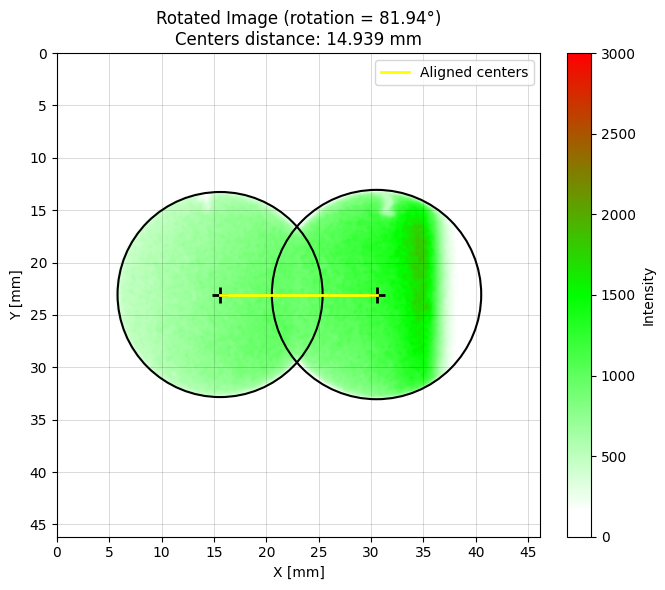

In [39]:
# Visualize rotated image with aligned circles
# Distance between circle centers
centers_distance_mm = np.sqrt(
    (circle2_rotated.x - circle1_rotated.x)**2 +
    (circle2_rotated.y - circle1_rotated.y)**2
) * PIXEL_SIZE_MM

fig, ax = plt.subplots(figsize=(14, 6))

h_rot, w_rot = image_rotated.shape
extent_mm = [0, w_rot * PIXEL_SIZE_MM, h_rot * PIXEL_SIZE_MM, 0]

im = ax.imshow(image_rotated, cmap=CMAP, vmin=0, vmax=VMAX, extent=extent_mm)

# Draw rotated circles
for circle, label, color in [
    (circle1_rotated, 'Left', 'black'),
    (circle2_rotated, 'Right', 'black')
]:
    cx_mm = circle.x * PIXEL_SIZE_MM
    cy_mm = circle.y * PIXEL_SIZE_MM
    r_mm = circle.r * PIXEL_SIZE_MM
    ax.add_patch(plt.Circle((cx_mm, cy_mm), r_mm, color=color, fill=False, lw=1.5))
    ax.plot(cx_mm, cy_mm, marker='+', color=color, ms=12, mew=2)

# Draw line between centers
ax.plot(
    [circle1_rotated.x * PIXEL_SIZE_MM, circle2_rotated.x * PIXEL_SIZE_MM],
    [circle1_rotated.y * PIXEL_SIZE_MM, circle2_rotated.y * PIXEL_SIZE_MM],
    'yellow', lw=2, label='Aligned centers'
)

ax.set_title(f'Rotated Image (rotation = {rotation_angle:.2f}°)\nCenters distance: {centers_distance_mm:.3f} mm')
ax.set_xlabel('X [mm]')
ax.set_ylabel('Y [mm]')

ax.set_xticks(np.arange(0, w_rot * PIXEL_SIZE_MM + 1, 5))
ax.set_yticks(np.arange(0, h_rot * PIXEL_SIZE_MM + 1, 5))
ax.grid(True, color='k', alpha=0.2, lw=0.5)

ax.legend()
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='Intensity')
plt.tight_layout()
plt.show()

## Profile Analysis

Circle center Y: 23.05 mm, radius: 9.79 mm
Centers distance: 14.939 mm
Profile Y range: 18-29 mm (12 profiles)


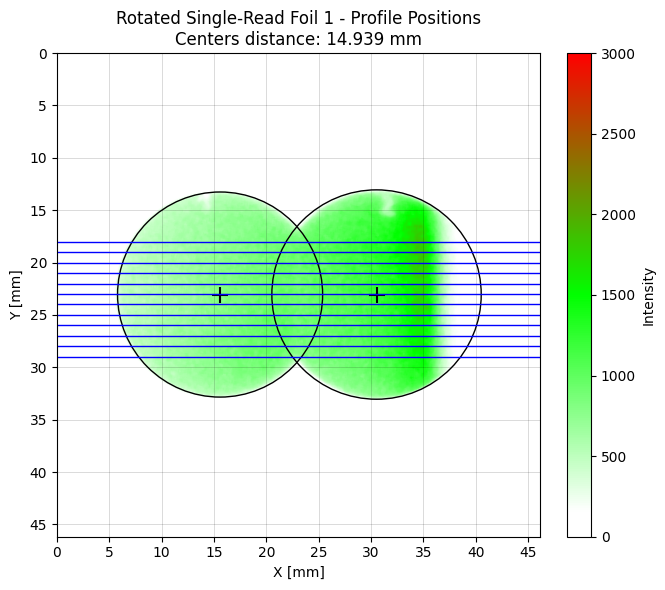

In [40]:
# Compute profile Y positions relative to circle centers
center_y_mm = circle1_rotated.y * PIXEL_SIZE_MM  # both circles have same Y after alignment
radius_mm = circle1_rotated.r * PIXEL_SIZE_MM

# Distance between circle centers
centers_distance_mm = np.sqrt(
    (circle2_rotated.x - circle1_rotated.x)**2 +
    (circle2_rotated.y - circle1_rotated.y)**2
) * PIXEL_SIZE_MM

# Profile lines: 18 to 29 mm range, every 1mm
profile_y_start = 18
profile_y_end = 29
profile_y_positions_mm = np.arange(profile_y_start, profile_y_end + 1, 1)

print(f"Circle center Y: {center_y_mm:.2f} mm, radius: {radius_mm:.2f} mm")
print(f"Centers distance: {centers_distance_mm:.3f} mm")
print(f"Profile Y range: {profile_y_start}-{profile_y_end} mm ({len(profile_y_positions_mm)} profiles)")

# Rotated image with profile lines marked
fig, ax = plt.subplots(figsize=(14, 6))

h_rot, w_rot = image_rotated.shape
extent_mm = [0, w_rot * PIXEL_SIZE_MM, h_rot * PIXEL_SIZE_MM, 0]

im = ax.imshow(image_rotated, cmap=CMAP, vmin=0, vmax=VMAX, extent=extent_mm)

# Draw rotated circles
for circle, label in [(circle1_rotated, 'Left'), (circle2_rotated, 'Right')]:
    cx_mm = circle.x * PIXEL_SIZE_MM
    cy_mm = circle.y * PIXEL_SIZE_MM
    r_mm = circle.r * PIXEL_SIZE_MM
    ax.add_patch(plt.Circle((cx_mm, cy_mm), r_mm, color='black', fill=False, lw=1))
    ax.plot(cx_mm, cy_mm, 'k+', ms=12, mew=1.5)

# Mark horizontal profile positions
for y_mm in profile_y_positions_mm:
    ax.axhline(y=y_mm, color='blue', linewidth=1)

ax.set_title(f'Rotated Single-Read Foil {FOIL_ID} - Profile Positions\nCenters distance: {centers_distance_mm:.3f} mm')
ax.set_xlabel('X [mm]')
ax.set_ylabel('Y [mm]')
ax.set_xticks(np.arange(0, w_rot * PIXEL_SIZE_MM + 1, 5))
ax.set_yticks(np.arange(0, h_rot * PIXEL_SIZE_MM + 1, 5))
ax.grid(True, color='k', alpha=0.2, lw=0.5)

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='Intensity')
plt.tight_layout()
plt.show()

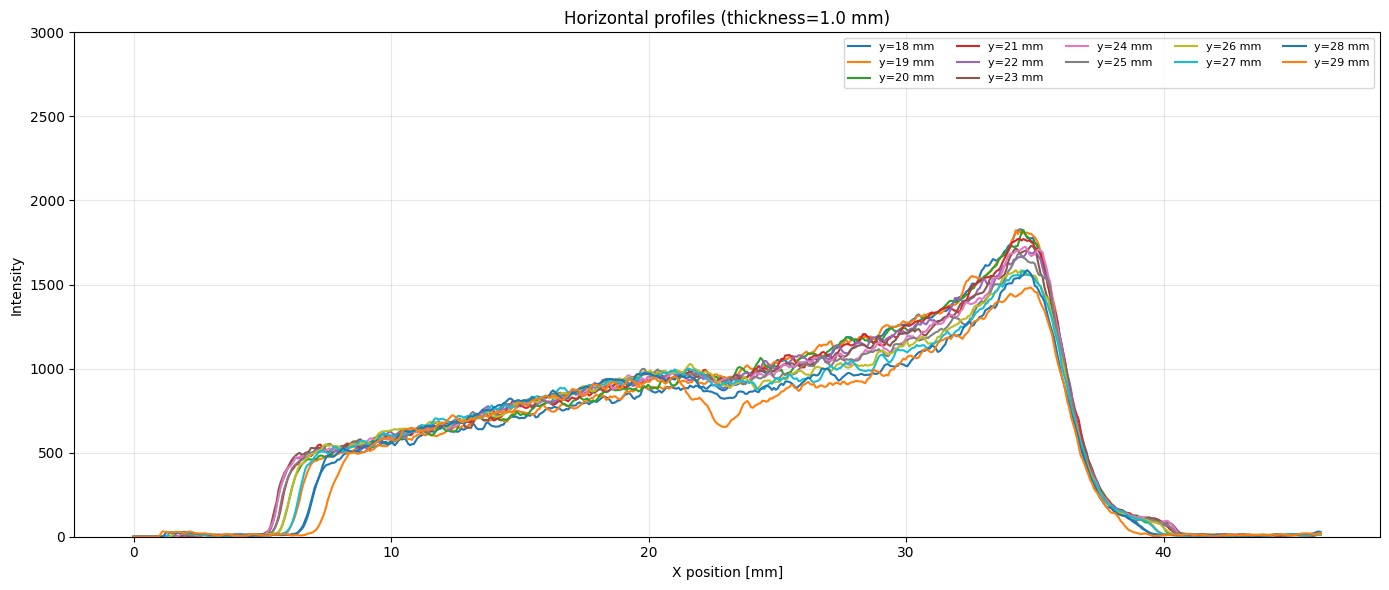

In [41]:
# Horizontal profiles at different y positions
fig, ax = plt.subplots(figsize=(14, 6))

thickness_mm = 1.0  # 1 mm thickness
thickness_px = int(thickness_mm / PIXEL_SIZE_MM)

# X axis in mm
x_mm = np.arange(image_rotated.shape[1]) * PIXEL_SIZE_MM

for y_mm in profile_y_positions_mm:
    y_px = int(y_mm / PIXEL_SIZE_MM)
    y0 = max(0, y_px - thickness_px // 2)
    y1 = min(image_rotated.shape[0], y_px + thickness_px // 2)
    profile = np.nanmean(image_rotated[y0:y1, :].astype(float), axis=0)
    ax.plot(x_mm, profile, label=f'y={y_mm:.0f} mm')

ax.set(xlabel='X position [mm]', ylabel='Intensity', ylim=(0, VMAX),
       title=f'Horizontal profiles (thickness={thickness_mm:.1f} mm)')
ax.legend(ncols=5, fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Profile Y range: 18-29 mm


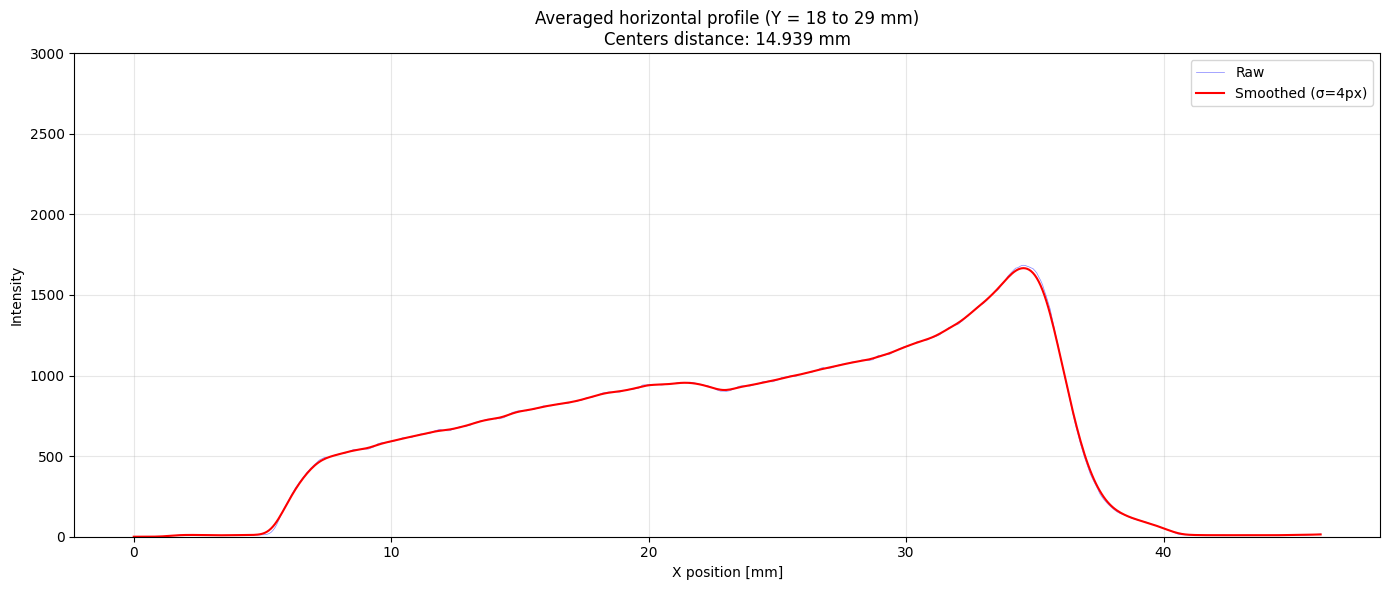

In [42]:
# Averaged horizontal profile — use 18-29 mm range
PROFILE_Y_MIN_MM = 18
PROFILE_Y_MAX_MM = 29
PROFILE_Y_MIN_PX = int(PROFILE_Y_MIN_MM / PIXEL_SIZE_MM)
PROFILE_Y_MAX_PX = int(PROFILE_Y_MAX_MM / PIXEL_SIZE_MM)
SMOOTHING_SIGMA = 4  # pixels

print(f"Profile Y range: {PROFILE_Y_MIN_MM}-{PROFILE_Y_MAX_MM} mm")

fig, ax = plt.subplots(figsize=(14, 6))

x_mm = np.arange(image_rotated.shape[1]) * PIXEL_SIZE_MM

# Calculate averaged profile
profile_raw = np.nanmean(image_rotated[PROFILE_Y_MIN_PX:PROFILE_Y_MAX_PX, :].astype(float), axis=0)

# Smooth with Gaussian filter
from scipy.ndimage import gaussian_filter1d
profile_smooth = gaussian_filter1d(profile_raw, sigma=SMOOTHING_SIGMA)

ax.plot(x_mm, profile_raw, 'b-', lw=0.5, alpha=0.5, label='Raw')
ax.plot(x_mm, profile_smooth, 'r-', lw=1.5, label=f'Smoothed (σ={SMOOTHING_SIGMA}px)')

ax.set(xlabel='X position [mm]', ylabel='Intensity', ylim=(0, VMAX),
       title=f'Averaged horizontal profile (Y = {PROFILE_Y_MIN_MM} to {PROFILE_Y_MAX_MM} mm)\nCenters distance: {centers_distance_mm:.3f} mm')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Center-Based Profile

Profile averaged over a stripe from the circle center Y position going up by 5 mm.

Circle centers Y: c1=23.05 mm, c2=23.05 mm
Average center Y: 23.05 mm
Center-based profile stripe: Y = 18.05 to 23.05 mm


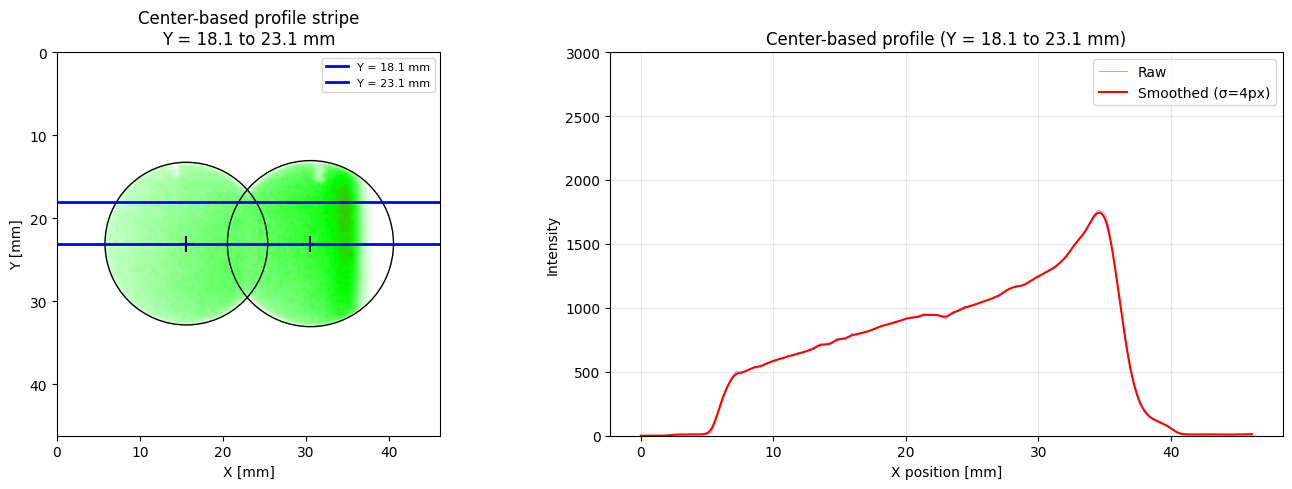

In [43]:
# Center-based profile: stripe from circle centers going up 5mm
# Average Y position of rotated circle centers (nearly equal after rotation)
avg_center_y_mm = (circle1_rotated.y + circle2_rotated.y) / 2 * PIXEL_SIZE_MM

# Stripe: from (center_y - 5mm) to center_y
CENTER_PROFILE_Y_MAX_MM = avg_center_y_mm
CENTER_PROFILE_Y_MIN_MM = avg_center_y_mm - 5
CENTER_PROFILE_Y_MIN_PX = int(CENTER_PROFILE_Y_MIN_MM / PIXEL_SIZE_MM)
CENTER_PROFILE_Y_MAX_PX = int(CENTER_PROFILE_Y_MAX_MM / PIXEL_SIZE_MM)

print(f"Circle centers Y: c1={circle1_rotated.y * PIXEL_SIZE_MM:.2f} mm, "
      f"c2={circle2_rotated.y * PIXEL_SIZE_MM:.2f} mm")
print(f"Average center Y: {avg_center_y_mm:.2f} mm")
print(f"Center-based profile stripe: Y = {CENTER_PROFILE_Y_MIN_MM:.2f} to {CENTER_PROFILE_Y_MAX_MM:.2f} mm")

# Compute center-based profile
x_mm_center = np.arange(image_rotated.shape[1]) * PIXEL_SIZE_MM
profile_center_raw = np.nanmean(
    image_rotated[CENTER_PROFILE_Y_MIN_PX:CENTER_PROFILE_Y_MAX_PX, :].astype(float), axis=0)
profile_center_smooth = gaussian_filter1d(profile_center_raw, sigma=SMOOTHING_SIGMA)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: image with stripe
ax = axes[0]
h_rot, w_rot = image_rotated.shape
extent_mm = [0, w_rot * PIXEL_SIZE_MM, h_rot * PIXEL_SIZE_MM, 0]
ax.imshow(image_rotated, cmap=CMAP, vmin=0, vmax=VMAX, extent=extent_mm)

for circle in [circle1_rotated, circle2_rotated]:
    ax.add_patch(plt.Circle((circle.x * PIXEL_SIZE_MM, circle.y * PIXEL_SIZE_MM),
                            circle.r * PIXEL_SIZE_MM, color='black', fill=False, lw=1))
    ax.plot(circle.x * PIXEL_SIZE_MM, circle.y * PIXEL_SIZE_MM, 'k+', ms=12, mew=1.5)

ax.axhline(y=CENTER_PROFILE_Y_MIN_MM, color='blue', linewidth=2, label=f'Y = {CENTER_PROFILE_Y_MIN_MM:.1f} mm')
ax.axhline(y=CENTER_PROFILE_Y_MAX_MM, color='blue', linewidth=2, label=f'Y = {CENTER_PROFILE_Y_MAX_MM:.1f} mm')
ax.set_title(f'Center-based profile stripe\nY = {CENTER_PROFILE_Y_MIN_MM:.1f} to {CENTER_PROFILE_Y_MAX_MM:.1f} mm')
ax.set_xlabel('X [mm]')
ax.set_ylabel('Y [mm]')
ax.legend(fontsize=8)

# Right: profile
ax = axes[1]
ax.plot(x_mm_center, profile_center_raw, 'b-', lw=0.5, alpha=0.5, label='Raw')
ax.plot(x_mm_center, profile_center_smooth, 'r-', lw=1.5, label=f'Smoothed (σ={SMOOTHING_SIGMA}px)')
ax.set_xlabel('X position [mm]')
ax.set_ylabel('Intensity')
ax.set_ylim(0, VMAX)
ax.set_title(f'Center-based profile (Y = {CENTER_PROFILE_Y_MIN_MM:.1f} to {CENTER_PROFILE_Y_MAX_MM:.1f} mm)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Save Results

In [44]:
# Save rotated image, circle coordinates, and profile data
output_path = DATA_PATH / f'single_read_foil_{FOIL_ID}.npz'

np.savez_compressed(
    output_path,
    # Rotated image
    image_rotated=image_rotated,
    # Circle coordinates in rotated frame
    circle1_x=circle1_rotated.x,
    circle1_y=circle1_rotated.y,
    circle1_r=circle1_rotated.r,
    circle2_x=circle2_rotated.x,
    circle2_y=circle2_rotated.y,
    circle2_r=circle2_rotated.r,
    # Profile data
    profile_x_mm=x_mm,
    profile_raw=profile_raw,
    profile_smooth=profile_smooth,
    profile_y_min_mm=PROFILE_Y_MIN_MM,
    profile_y_max_mm=PROFILE_Y_MAX_MM,
    smoothing_sigma_px=SMOOTHING_SIGMA,
    # Center-based profile (stripe from circle center Y going up 5mm)
    profile_center_x_mm=x_mm_center,
    profile_center_raw=profile_center_raw,
    profile_center_smooth=profile_center_smooth,
    profile_center_y_min_mm=CENTER_PROFILE_Y_MIN_MM,
    profile_center_y_max_mm=CENTER_PROFILE_Y_MAX_MM,
    # Metadata
    rotation_angle_deg=rotation_angle,
    pixel_size_mm=PIXEL_SIZE_MM,
    foil_id=FOIL_ID
)
print(f"Saved to: {output_path}")

Saved to: C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\foils_mbo_ccb\2026-02-20\single_read_foil_1.npz
